# 01 — Music Feature Extraction

Extract symbolic music features from the MIDI files identified in notebook 00 using the
[**DIDONEproject/music_symbolic_features**](https://github.com/DIDONEproject/music_symbolic_features)
pipeline — which orchestrates **musif**, **music21**, and **jSymbolic** in an isolated
Python 3.10 environment.

**Pipeline**
1. One-time setup: `bash scripts/setup_didone.sh`
2. Run feature extraction: `bash scripts/extract_features.sh`
3. Load & merge the three extractor CSVs with `load_didone_features` / `merge_didone_features`
4. Post-process, inspect distributions & correlations
5. Merge with MSD metadata and save to `data/processed/music_features.parquet`

> **Fallback**: If the DIDONE pipeline has not been run yet, this notebook
> falls back to direct `musif` extraction via `batch_extract()`.


In [ ]:
import sys, pathlib, os, subprocess, shutil
if str(pathlib.Path(os.getcwd()).name) == 'DL-KG-project':
    os.chdir('notebooks')
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET
import music21

from data.music_feature_extraction import (
    # DIDONE pipeline (primary)
    load_didone_features,
    merge_didone_features,
    DIDONE_EXTRACTORS,
    # direct musif (fallback)
    extract_musif_features,
    postprocess_features,
    batch_extract,
    DEFAULT_FEATURES,
)

sns.set_theme(style='whitegrid')
print("Imports OK")


Imports OK


## 1 — Configuration

In [ ]:
REPO_ROOT        = pathlib.Path('..').resolve()
RAW_DIR          = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR    = REPO_ROOT / 'data' / 'processed'
INTERIM_DIR      = REPO_ROOT / 'data' / 'interim'

# ── input ─────────────────────────────────────────────────────────────────────
DATASET_PARQUET  = PROCESSED_DIR / 'lakh_msd_dataset.parquet'
PER_SONG_STATS  = PROCESSED_DIR / "taste_profile_per_song.csv"

# ── DIDONE pipeline paths ─────────────────────────────────────────────────────
MUSIC_FEATURES    = INTERIM_DIR / 'music_features'
DATASET_NAME     = 'lmd_matched'                     # folder inside DIDONE_OUTPUT
MIDI_DIR         = RAW_DIR / 'lmd_matched'

# ── Interim output paths ───────────────────────────────────────────────────────
INTERIM_MIDI_DIR = INTERIM_DIR / "midi_dir"
JSYMBOLIC_FEATURES = MUSIC_FEATURES / "jsymbolic_features.csv"
MUSIC21_FEATURES = MUSIC_FEATURES / "music21_features.csv"

# ── output ────────────────────────────────────────────────────────────────────
FEATURES_PARQUET = PROCESSED_DIR / 'music_features.parquet'
MERGED_PARQUET   = PROCESSED_DIR / 'lakh_msd_with_features.parquet'

# ── fallback (direct musif) settings ──────────────────────────────────────────
CHUNK_SIZE  = 100          # files per musif call
MAX_FILES   = None         # int for a quick test, None = all
FEATURES    = DEFAULT_FEATURES

print(f"Music features output dir : {MUSIC_FEATURES}")
print(f"Dataset name      : {DATASET_NAME}")
print(f"Features parquet  : {FEATURES_PARQUET}")

JSYMBOLIC_DIR = REPO_ROOT / 'jSymbolic'
JSYMBOLIC_CONFIG = JSYMBOLIC_DIR / 'jSymbolicConfig.txt'
JSYMBOLIC_PATH = JSYMBOLIC_DIR / 'jSymbolic2.jar'

Music features output dir : C:\Users\aarthi\Documents\Uni\Y1\S2\KGDL\DL-KG-project\data\interim\music_features
Dataset name      : lmd_matched
Features parquet  : C:\Users\aarthi\Documents\Uni\Y1\S2\KGDL\DL-KG-project\data\processed\music_features.parquet


## 2 — Music Feature Extraction

In [3]:
#Preload existing interim dataframes
lakh_df = pd.read_parquet(DATASET_PARQUET)
per_song_df = pd.read_csv(PER_SONG_STATS)

In [ ]:
if not os.path.isdir(INTERIM_DIR):
    os.mkdir(INTERIM_DIR)

if not os.path.isdir(MUSIC_FEATURES):
    os.mkdir(MUSIC_FEATURES)

if not os.path.exists(JSYMBOLIC_FEATURES):
    for i in range(((len(per_song_df)-1)//CHUNK_SIZE)+1):
        #Copy every song to one location so jSymbolic can run on all of them in one go, avoiding startup overhead
        if not os.path.isdir(INTERIM_MIDI_DIR):
            os.mkdir(INTERIM_MIDI_DIR)

        for j, row in per_song_df[i*CHUNK_SIZE:i*CHUNK_SIZE+CHUNK_SIZE].iterrows():
            lakh_row = lakh_df.loc[lakh_df['song_id'] == row['song_id']]
            source_midi_path = list(lakh_row['midi_path'])[0]
            target_midi_path = INTERIM_MIDI_DIR / os.path.basename(source_midi_path)
            shutil.copyfile(source_midi_path, target_midi_path)

        incomplete = True
        while incomplete:
            #Try adding '-Xmx12g' before '-jar'
            result = subprocess.run(['java', '-jar', JSYMBOLIC_PATH, '-configrun', JSYMBOLIC_CONFIG, INTERIM_MIDI_DIR, MUSIC_FEATURES / "feature_values.xml", MUSIC_FEATURES / "feature_definitions.xml"], capture_output=True)
            if len(result.stderr) > 0:
                err_string = str(result.stderr)
                idx = err_string.find('.mid')
                if idx > -1: #Remove MIDI files which we were unable to extract features from
                    filename = err_string[idx-32:idx+4]
                    os.remove(INTERIM_MIDI_DIR / filename)
            else:
                incomplete = False

            print(result.stdout)
            print(result.stderr)
        shutil.rmtree(INTERIM_MIDI_DIR)

        if not os.path.exists(JSYMBOLIC_FEATURES):
            shutil.copyfile(MUSIC_FEATURES / "feature_values.csv", JSYMBOLIC_FEATURES)
        else:
            new_file = open(MUSIC_FEATURES / "feature_values.csv", 'r')
            feature_txt_data = new_file.read()
            new_file.close()
            idx = feature_txt_data.find("\n")

            interim_file = open(JSYMBOLIC_FEATURES, 'a')
            interim_file.write(feature_txt_data[idx+1:])
            interim_file.close()

In [12]:
#Associate music features with song_id instead of MIDI file path
jsymbolic_features_df = pd.read_csv(JSYMBOLIC_FEATURES)
for i, row in jsymbolic_features_df.iterrows():
    lakh_row = lakh_df.loc[lakh_df['midi_path'].str.contains(os.path.basename(row['Unnamed: 0']))]
    song_id = list(lakh_row['song_id'])[0]
    # jsymbolic_features_df['Unnamed: 0', i] = song_id
    jsymbolic_features_df.iloc[[i],[0]] = song_id

#Some rows are duplicated, remove them
jsymbolic_features_df = jsymbolic_features_df.drop_duplicates()
jsymbolic_features_df.rename({'Unnamed: 0': 'song_id'}, axis=1, inplace=True)

In [ ]:
#music21 native feature extraction
extractors = []
for feature in music21.features.base.extractorsById("all"):
    if not ('jSymbolic' in feature.__module__):
        extractors += [feature]

if not os.path.exists(MUSIC21_FEATURES): #Skip if feature extraction already done
    for i in range(((len(per_song_df)-1)//CHUNK_SIZE)+1):
        music21_dataset = music21.features.base.DataSet(featureExtractors=extractors, classLabel='song_id')

        for j, row in per_song_df[i*CHUNK_SIZE:i*CHUNK_SIZE+CHUNK_SIZE].iterrows():
            lakh_row = lakh_df.loc[lakh_df['song_id'] == row['song_id']]
            music21_dataset.addData(list(lakh_row['midi_path'])[0], classValue=row['song_id'])

        music21_dataset.process()
        tempfile = MUSIC_FEATURES / "temp.csv"
        music21_dataset.write(str(tempfile))

        if not os.path.exists(MUSIC21_FEATURES):
            shutil.copyfile(tempfile, MUSIC21_FEATURES)
        else:
            new_file = open(tempfile, 'r')
            feature_txt_data = new_file.read()
            idx = feature_txt_data.find("\n")
            new_file.close()
            outfile = open(MUSIC21_FEATURES, 'a')
            outfile.write(feature_txt_data[idx:])
            outfile.close()

        print(f"Processed chunk {i}")

## 3 — Merge Feature CSVs

Load each extractor's output and merge into a single wide DataFrame.
to prevent naming collisions.


In [ ]:
#Associate music features with song_id instead of MIDI file path
music21_features_df = pd.read_csv(MUSIC21_FEATURES)
music21_features_df = music21_features_df.drop(columns=['Identifier'])

print(music21_features_df.shape)
print(jsymbolic_features_df.shape)
music_features_df = pd.merge(music21_features_df, jsymbolic_features_df, 'left', 'song_id')

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
# Save features alone
music_features_df.to_parquet(FEATURES_PARQUET, index=False)
print(f"Features saved → {FEATURES_PARQUET}  ({music_features_df.shape})")

(7050, 32)
(7013, 1496)
['Quality', 'Tonal_Certainty', 'Unique_Note_Quarter_Lengths', 'Most_Common_Note_Quarter_Length', 'Most_Common_Note_Quarter_Length_Prevalence', 'Range_of_Note_Quarter_Lengths', 'Unique_Pitch_Class_Set_Simultaneities', 'Unique_Set_Class_Simultaneities', 'Most_Common_Pitch_Class_Set_Simultaneity_Prevalence', 'Most_Common_Set_Class_Simultaneity_Prevalence', 'Major_Triad_Simultaneity_Prevalence', 'Minor_Triad_Simultaneity_Prevalence', 'Dominant_Seventh_Simultaneity_Prevalence', 'Diminished_Triad_Simultaneity_Prevalence', 'Triad_Simultaneity_Prevalence', 'Diminished_Seventh_Simultaneity_Prevalence', 'Incorrectly_Spelled_Triad_Prevalence', 'Chord_Bass_Motion_0', 'Chord_Bass_Motion_1', 'Chord_Bass_Motion_2', 'Chord_Bass_Motion_3', 'Chord_Bass_Motion_4', 'Chord_Bass_Motion_5', 'Chord_Bass_Motion_6', 'Chord_Bass_Motion_7', 'Chord_Bass_Motion_8', 'Chord_Bass_Motion_9', 'Chord_Bass_Motion_10', 'Chord_Bass_Motion_11', 'Ends_With_Landini_Melodic_Contour', 'Language_Feature', 

## 6 — Feature exploration


In [31]:
num_df   = music_features_df.select_dtypes(include='number')
nan_rate = num_df.isnull().mean().sort_values()

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: NaN rate histogram
# axes[0].hist(nan_rate.values, bins=40, color='steelblue', edgecolor='white')
# axes[0].set(title='NaN Rate Distribution (numeric columns)',
#             xlabel='Fraction NaN', ylabel='# Columns')

# # Right: distributions of a few candidate features (prefix-agnostic search)
# _cands = ['Mean_Tempo', 'Note_Density', 'Number_of_Pitches', 'Average_Note_Duration']
# key_cols = [c for c in num_df.columns
#             if any(kw.lower() in c.lower() for kw in ['tempo','ambitus','density','pitch'])][:6]

# for col in key_cols:
#     axes[1].hist(num_df[col].dropna(), bins=50, alpha=0.6, label=col.split('__')[-1])
# axes[1].set(title='Selected Feature Distributions', xlabel='Value', ylabel='Count')
# if key_cols:
#     axes[1].legend(fontsize=7)

# plt.tight_layout()
# plt.show()

print(f"Total numeric features: {len(num_df.columns)}")
print(f"Median NaN rate: {nan_rate.median():.1%}")


Total numeric features: 1525
Median NaN rate: 0.5%


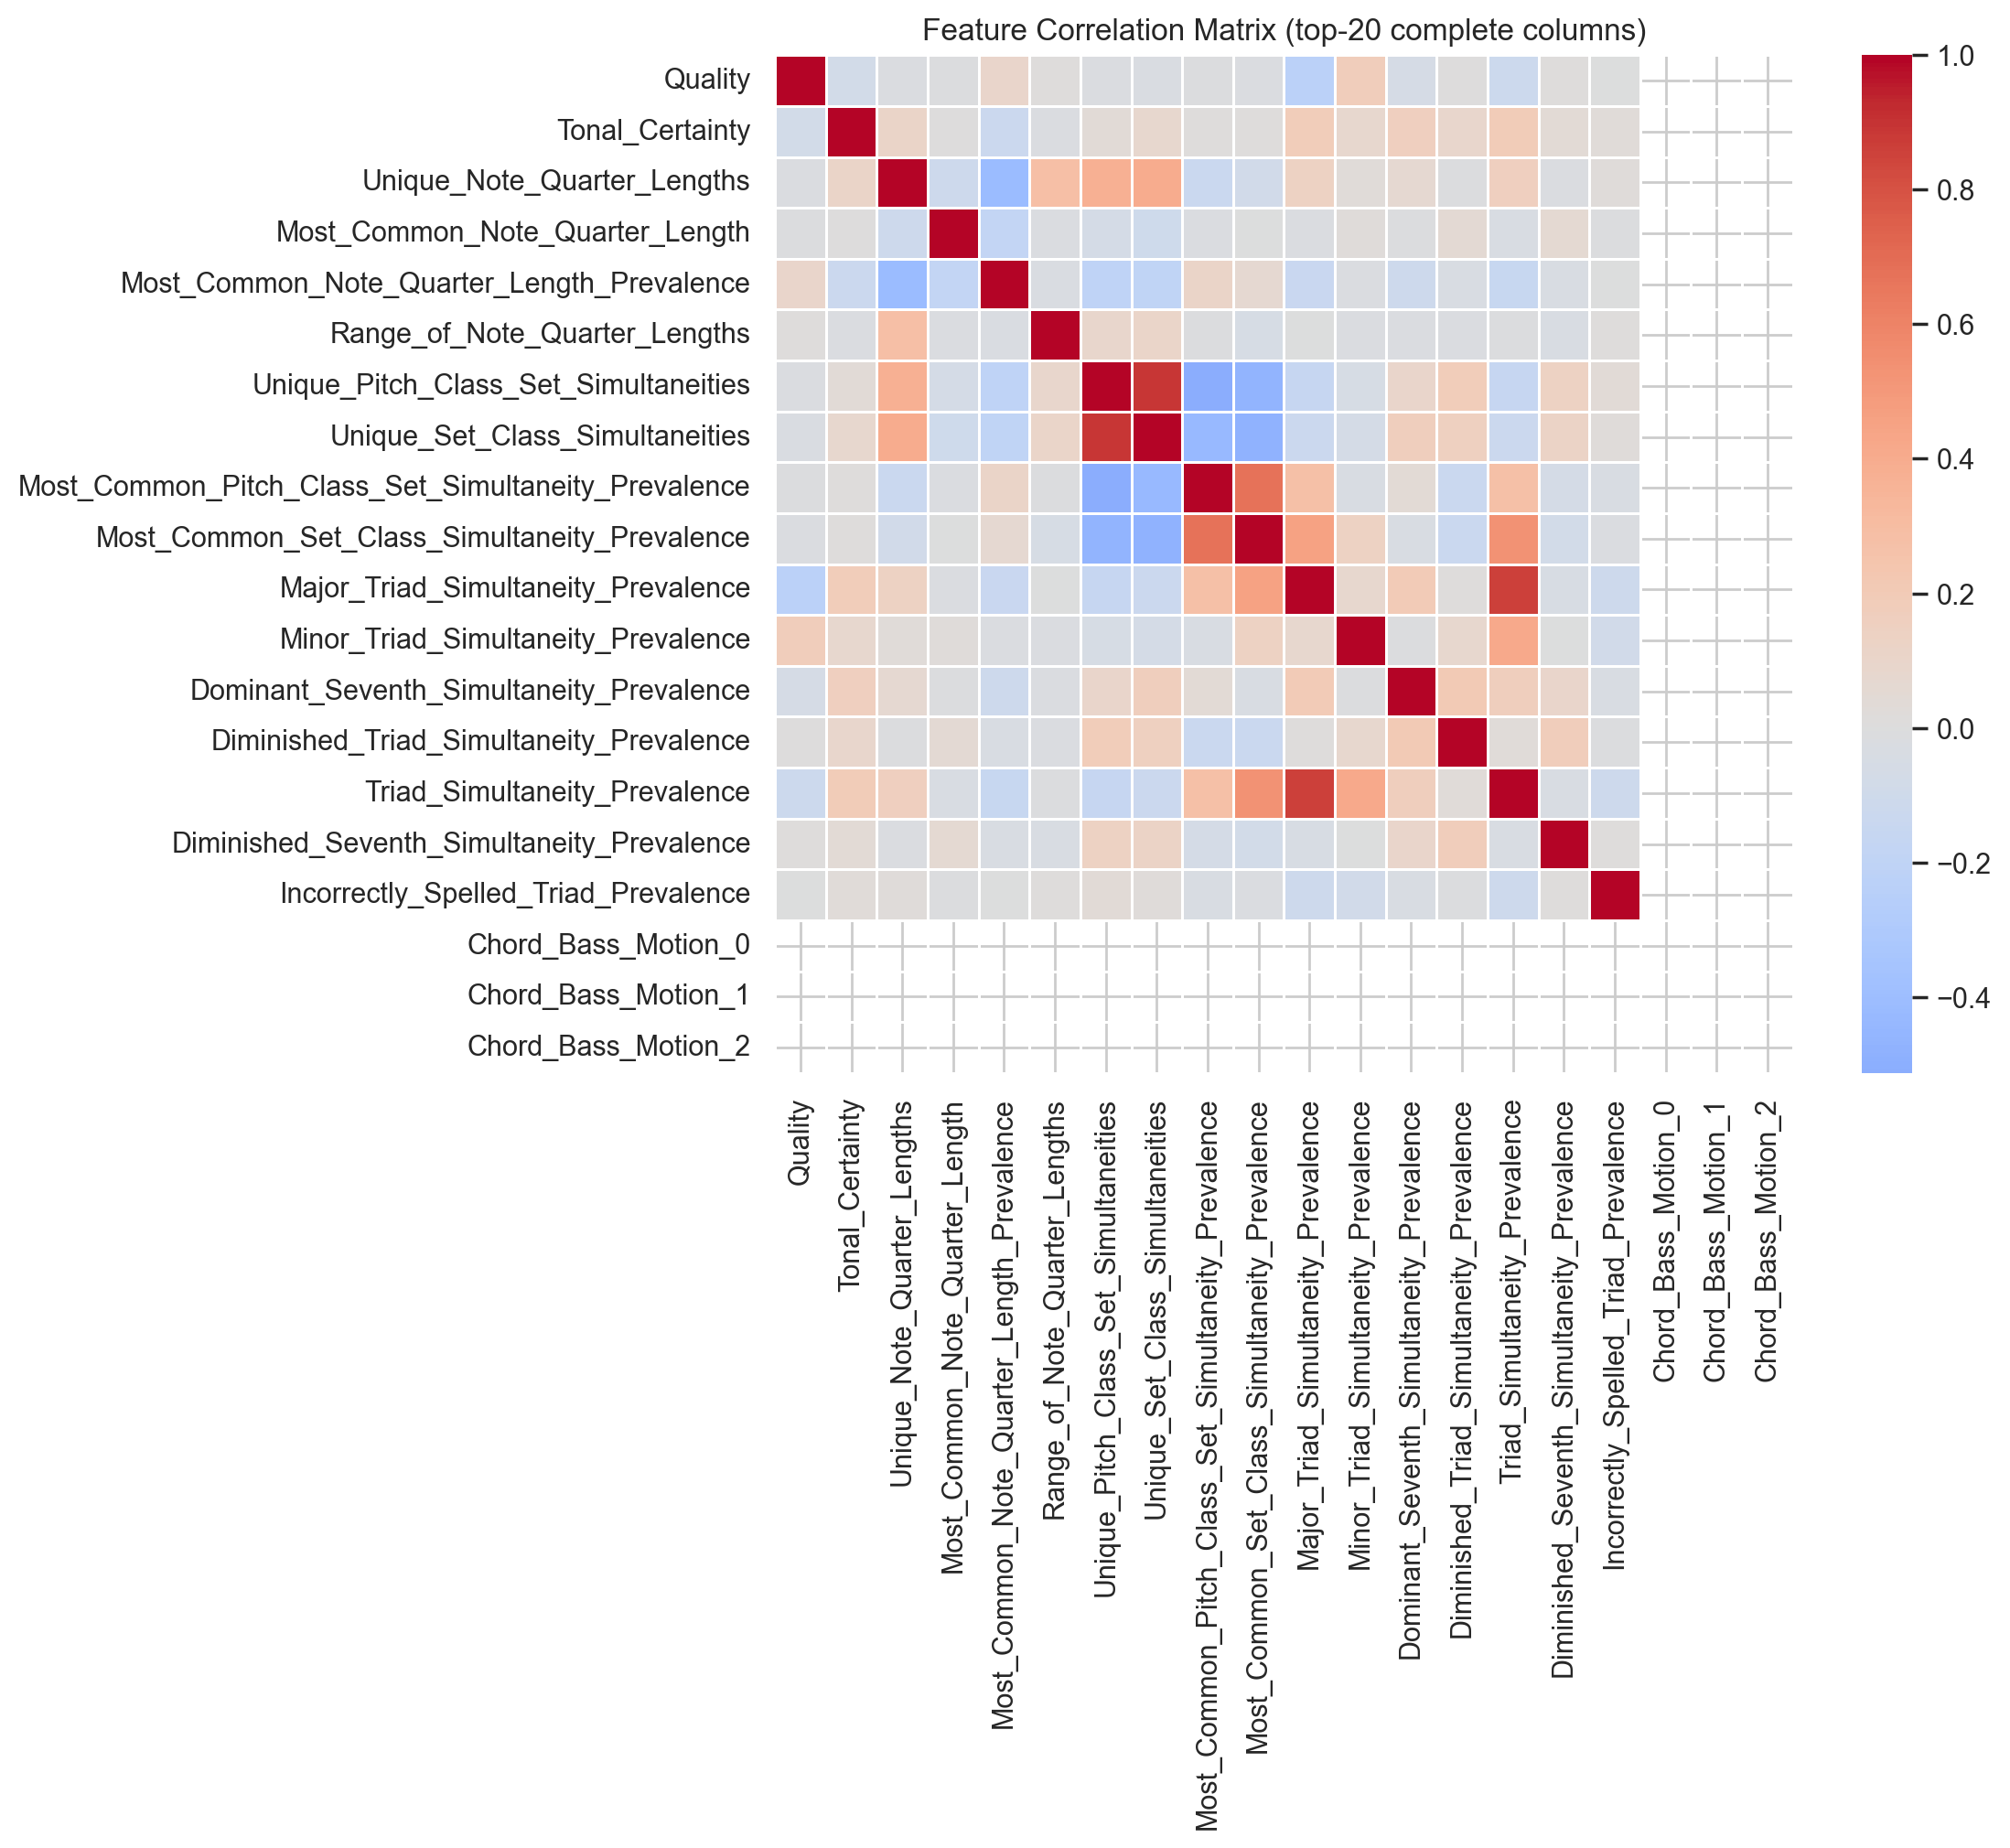

In [32]:
# Correlation heatmap — top 20 most-complete numeric features
top20 = nan_rate.index[:20].tolist()
corr  = num_df[top20].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.4, square=True)
plt.title('Feature Correlation Matrix (top-20 complete columns)')
plt.tight_layout()
plt.show()

## 6 — Merge with metadata & save final feature table

In [48]:
lakh_df_filtered = lakh_df[lakh_df['song_id'].isin(per_song_df['song_id'])]
print(lakh_df_filtered.shape)
print(music_features_df.shape)

merged = pd.merge(lakh_df_filtered, music_features_df, 'left', 'song_id')
print(merged.shape)

merged.to_parquet(MERGED_PARQUET, index=False)
print(f"Merged  saved → {MERGED_PARQUET}  ({merged.shape})")
merged.head(2)


(7050, 51)
(7050, 1527)
(7050, 1577)
Merged  saved → C:\Users\aarthi\Documents\Uni\Y1\S2\KGDL\DL-KG-project\data\processed\lakh_msd_with_features.parquet  ((7050, 1577))


,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,artist_playmeid,artist_7digitalid,release_7digitalid,track_7digitalid,...,Parallel_Motion,Similar_Motion,Contrary_Motion,Oblique_Motion,Parallel_Fifths,Parallel_Octaves,Dynamic_Range,Variation_of_Dynamics,Variation_of_Dynamics_In_Each_Voice,Average_Note_to_Note_Change_in_Dynamics
0,TRPDJVL128F1495E0B,C:\Users\aarthi\Documents\Uni\Y1\S2\KGDL\DL-KG...,0.550041,SOYUXZJ12A6D4F86F1,ARL7SZI1187FB4E78F,8a3cf5e4-2a31-4a5f-b616-5eca012a698e,-1,31612,53746,560512,...,0.05884,0.3267,0.06472,0.5498,0.007296,0.011060,84.0,17.13,7.838,8.057
1,TROLENX128F9330D31,C:\Users\aarthi\Documents\Uni\Y1\S2\KGDL\DL-KG...,0.550818,SOBFFEN12A6701C878,ARQT9SA1187B9AD3C7,e01c3376-15fa-40d7-b747-5f219bdefdd7,3080,4025,506664,5605502,...,0.04105,0.3088,0.04918,0.6009,0.004769,0.004301,81.0,15.26,8.621,9.261
